## 1. 분류 활용

#### SelectKBest
 - 카이제곱통계량, 상호정보량, F통계량 등 이용
 - chi2, mutual_info_classif, mutual_info_regression, f_classif, f_regression


In [43]:
import pandas as pd

data = pd.read_csv("secom.data", sep="\s", header=None)
data.columns = ["X"+str(i) for i in range(0, 590)]
X_cols = data.columns

y = pd.read_csv("secom_labels.data",
                 sep=' ',
                 header=None,
                 names=['label', 'datetime'],
                 quotechar='"')

# 문자열을 datetime 형식으로 변환
y['datetime'] = pd.to_datetime(y['datetime'], format="%d/%m/%Y %H:%M:%S")
y.head()

<>:3: SyntaxWarning: invalid escape sequence '\s'
<>:3: SyntaxWarning: invalid escape sequence '\s'
C:\Users\user\AppData\Local\Temp\ipykernel_29168\2983796615.py:3: SyntaxWarning: invalid escape sequence '\s'
  data = pd.read_csv("secom.data", sep="\s", header=None)
C:\Users\user\AppData\Local\Temp\ipykernel_29168\2983796615.py:3: ParserWarning: Falling back to the 'python' engine because the 'c' engine does not support regex separators (separators > 1 char and different from '\s+' are interpreted as regex); you can avoid this warning by specifying engine='python'.
  data = pd.read_csv("secom.data", sep="\s", header=None)


,label,datetime
0,-1,2008-07-19 11:55:00
1,-1,2008-07-19 12:32:00
2,1,2008-07-19 13:17:00
3,-1,2008-07-19 14:43:00
4,-1,2008-07-19 15:22:00


In [44]:
from sklearn.impute import SimpleImputer
imputer = SimpleImputer(strategy="median")
imputer.fit(data)
data = imputer.transform(data)

In [45]:
y_new = pd.get_dummies(y.label, drop_first=True).astype(int)

In [46]:
from sklearn.feature_selection import *
selector = SelectKBest(f_classif, k=100)
selector.fit(data, y.label)

X_new = selector.transform(data)
#selected = X_train.columns[selector.get_support()]
selector.scores_
X_new.shape


c:\Users\user\miniconda3\envs\day3\Lib\site-packages\sklearn\feature_selection\_univariate_selection.py:110: UserWarning: Features [  5  13  42  49  52  69  97 141 149 178 179 186 189 190 191 192 193 194
 226 229 230 231 232 233 234 235 236 237 240 241 242 243 256 257 258 259
 260 261 262 263 264 265 266 276 284 313 314 315 322 325 326 327 328 329
 330 364 369 370 371 372 373 374 375 378 379 380 381 394 395 396 397 398
 399 400 401 402 403 404 414 422 449 450 451 458 461 462 463 464 465 466
 481 498 501 502 503 504 505 506 507 508 509 512 513 514 515 528 529 530
 531 532 533 534 535 536 537 538] are constant.
  warnings.warn("Features %s are constant." % constant_features_idx, UserWarning)
c:\Users\user\miniconda3\envs\day3\Lib\site-packages\sklearn\feature_selection\_univariate_selection.py:111: RuntimeWarning: invalid value encountered in divide
  f = msb / msw


(1567, 100)

In [47]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test =  train_test_split( X_new, y_new, test_size=0.2, random_state=2022)


## 2. 머신러닝 파이프라인


In [48]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import MinMaxScaler
from sklearn.svm import SVC
scaler = MinMaxScaler()
model = SVC()

P = Pipeline([("imputer", imputer),("scaler", scaler),("model", model)])
P.fit(X_train, y_train)
P.predict(X_test)


c:\Users\user\miniconda3\envs\day3\Lib\site-packages\sklearn\utils\validation.py:1352: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,

In [49]:
P = Pipeline([("imputer", imputer),("scaler", scaler)])
P.fit(X_train, y_train)
P.transform(X_test)

array([[0.44119858, 0.28673823, 0.71911111, ..., 0.1513615 , 0.18645675,
        0.14349613],
       [0.37398538, 0.23530646, 0.70495726, ..., 0.55887324, 0.58516692,
        0.67966217],
       [0.35931827, 0.11202406, 0.61852991, ..., 0.13342723, 0.16236722,
        0.1395991 ],
       ...,
       [0.34877899, 0.24170484, 0.71466667, ..., 0.58868545, 0.67033384,
        0.65752705],
       [0.52620077, 0.24153002, 0.72731624, ..., 0.1141784 , 0.14491654,
        0.09322881],
       [0.3417663 , 0.09513653, 0.82646154, ..., 0.16178404, 0.16540212,
        0.12626153]], shape=(314, 100))

#### pickle

In [50]:
import pickle
with open("model1.pckl", "wb") as f:
  pickle.dump(imputer,f)
  pickle.dump(scaler,f)
  pickle.dump(model,f)


In [51]:
with open("model1.pckl", "rb") as f:
  imputer = pickle.load(f)
  scaler = pickle.load(f)
  model = pickle.load(f)

In [52]:
pipe = {"imputer": imputer, "scaler":scaler, "model":model}
with open("model1.pckl", "wb") as f:
  pickle.dump(pipe,f)

## 3. DT & Imbalanced Target

- Class 가중치: 소수 범주에 가중치를 반영하여 모델링에 활용 (소수 범주에 가점)
 - 예: 다수 범주0, 소수 범주 1, 다수 범주가 8배 많은 경우

In [53]:
y_new.value_counts()
1463/104

14.067307692307692

In [54]:
from sklearn.tree import DecisionTreeClassifier
dt = DecisionTreeClassifier( class_weight={0:1, 1:14.07})
dt.fit(X_train, y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the curre

In [55]:
from sklearn.metrics import classification_report
pred = dt.predict(X_test)
print(classification_report(y_test, pred))

              precision    recall  f1-score   support

           0       0.95      0.94      0.94       296
           1       0.10      0.11      0.11        18

    accuracy                           0.89       314
   macro avg       0.52      0.53      0.52       314
weighted avg       0.90      0.89      0.89       314



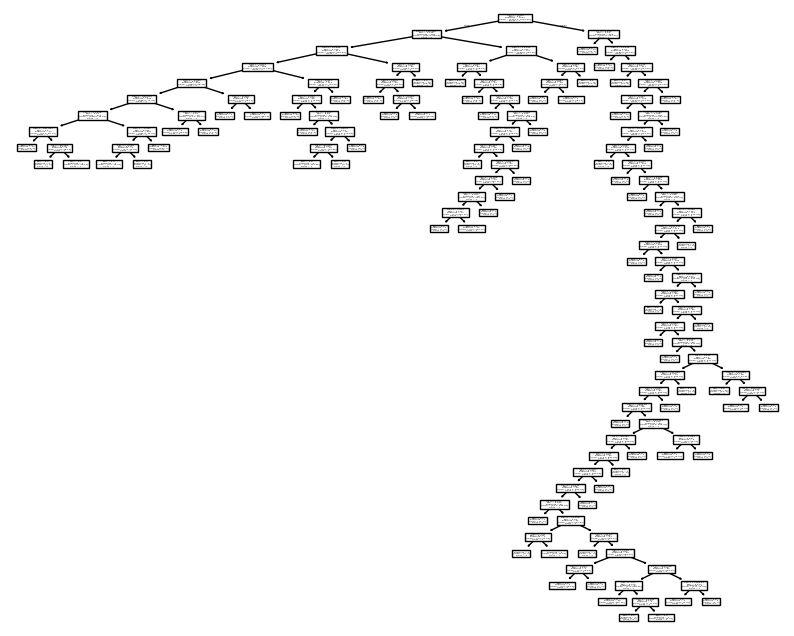

In [56]:
from sklearn.tree import plot_tree
from matplotlib import pyplot as plt
plt.figure( figsize =(10,8))
plot_tree( dt, feature_names=X_cols, class_names=["0","1"])
plt.show()

In [57]:
X_cols2 = X_cols[selector.get_support()]

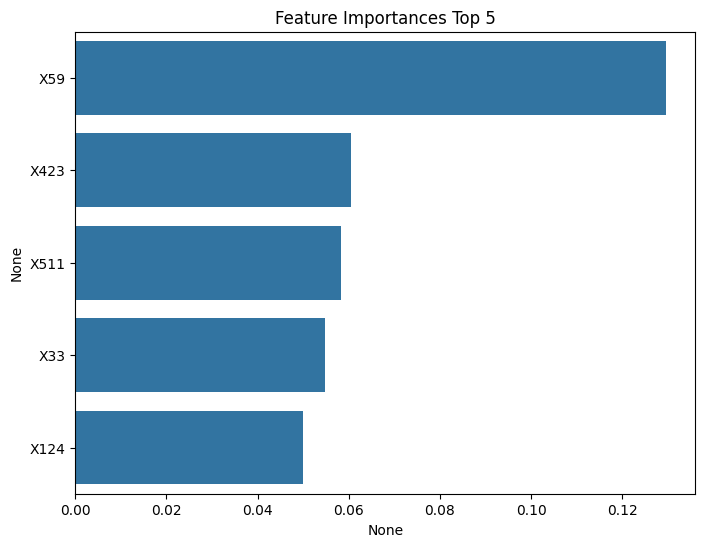

In [58]:
# Feature Importance

import seaborn as sns
feature_importance_values = dt.feature_importances_
feature_importances = pd.Series(feature_importance_values, index=X_cols2)
feature_top5 = feature_importances.sort_values(ascending=False)[:5]

plt.figure(figsize=[8, 6])
plt.title('Feature Importances Top 5')
sns.barplot(x=feature_top5, y=feature_top5.index)
plt.show()

## 4. DT 규칙 추출

In [59]:
from sklearn.tree import DecisionTreeRegressor
model = DecisionTreeRegressor(max_depth = 5).fit(X_train, y_train)

In [60]:
from sklearn.tree import export_text
def text_to_rule_list(r):
    node_list = []
    leaf_node_list = []

    for i, node in enumerate(r.split("\n")[:-1]):
        rule = node.split('- ')[1]
        indent = node.count(' ' * 3)
        if 'value' in rule:
            leaf_node_list.append([i, rule, indent])
        node_list.append([i, rule, indent])

    prediction_rule_list = []
    for leaf_node in leaf_node_list:
        prediction_rule = []
        idx, decision, indent = leaf_node
        for indent_level in range(indent-1, -1, -1):
            for node_idx in range(idx, -1, -1):
                node = node_list[node_idx]
                rule = node[1]
                if node[2] == indent_level and "value" not in node[1]:
                    prediction_rule.append(rule)
                    break
        prediction_rule_list.append([prediction_rule, decision])

    return prediction_rule_list

In [61]:
r = export_text(model)
result = pd.DataFrame(text_to_rule_list(r),
                      columns = ["condition", "output"])
display(result.head())

,condition,output
0,"[feature_79 <= 29.34, feature_29 <= 16.06, fea...",value: [0.03]
1,"[feature_79 > 29.34, feature_29 <= 16.06, fea...",value: [1.00]
2,"[feature_62 <= 4.96, feature_29 > 16.06, feat...",value: [1.00]
3,"[feature_62 > 4.96, feature_29 > 16.06, feat...",value: [0.13]
4,"[feature_56 <= 252.80, feature_9 > 84.77, fea...",value: [1.00]


In [62]:
def extract_float(output):
    output = output.split('[')[1]
    output = float(output[:-1])
    return output

result['condition'] = result['condition'].apply(' & '.join)
result['output'] = result['output'].apply(extract_float)
result.sort_values(by = "output", inplace = True)

In [63]:
result.head()

,condition,output
7,feature_10 <= 0.93 & feature_98 > 0.07 & feat...,0.00
5,feature_56 > 252.80 & feature_9 > 84.77 & fe...,0.00
16,feature_87 <= 98.77 & feature_77 > 4.85 & fea...,0.00
0,feature_79 <= 29.34 & feature_29 <= 16.06 & fe...,0.03
12,feature_13 <= 30.07 & feature_13 > 13.35 & fe...,0.03


## 5. 이미지 적용

- wafer 이미지 처리

In [64]:
import numpy as np
from PIL import Image
import os, glob, random

max_photo = 150
photo_size=32

In [65]:
import os
import glob
import random
dirs = os.listdir("Dataset")

In [66]:
def img_read(dir):
  files = glob.glob( "Dataset/"+dir+"/*.jpg")
  #random.shuffle(files)
  num=0
  tmp1 = []
  tmp2 = []
  print(len(files), dir, num)
  for f in files:
    print(f)
    if num >= max_photo: break
    num +=1
    img = Image.open(f)
    img= img.convert("RGB")
    img= img.resize((photo_size, photo_size))
    img= np.asarray(img)
    tmp1.append(img)
    tmp2.append(dir)	#label을 0으로 지정
  return tmp1, tmp2

In [67]:
x=[]
y=[]

for dir in dirs:
  print(dir)
  x1, y1 = img_read(dir)
  x.append(x1)
  y.append(y1)

Center
100 Center 0
Dataset/Center\641447.jpg
Dataset/Center\642989.jpg
Dataset/Center\646177.jpg
Dataset/Center\648236.jpg
Dataset/Center\651816.jpg
Dataset/Center\655870.jpg
Dataset/Center\659673.jpg
Dataset/Center\678673.jpg
Dataset/Center\679609.jpg
Dataset/Center\680688.jpg
Dataset/Center\682743.jpg
Dataset/Center\683806.jpg
Dataset/Center\686597.jpg
Dataset/Center\687416.jpg
Dataset/Center\691371.jpg
Dataset/Center\692645.jpg
Dataset/Center\696055.jpg
Dataset/Center\712477.jpg
Dataset/Center\713551.jpg
Dataset/Center\720828.jpg
Dataset/Center\723088.jpg
Dataset/Center\724684.jpg
Dataset/Center\727923.jpg
Dataset/Center\732235.jpg
Dataset/Center\740416.jpg
Dataset/Center\755691.jpg
Dataset/Center\757377.jpg
Dataset/Center\758049.jpg
Dataset/Center\759637.jpg
Dataset/Center\760560.jpg
Dataset/Center\760845.jpg
Dataset/Center\761305.jpg
Dataset/Center\761994.jpg
Dataset/Center\762126.jpg
Dataset/Center\762236.jpg
Dataset/Center\762524.jpg
Dataset/Center\762821.jpg
Dataset/Center\763

In [68]:
x_final = [item for sublist in x for item in sublist]
y_final = [item for sublist in y for item in sublist]

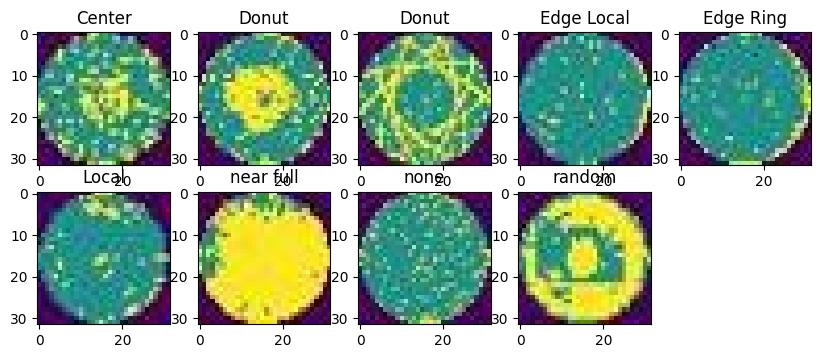

In [69]:
#이미지 출력
import matplotlib.pyplot as plt
idx = 100
plt.figure(figsize=(10,10))
for i in range(9):
 plt.subplot(5,5,i+1)
 plt.title(y_final[i*idx])
 plt.imshow(x_final[i*idx])
plt.show()

#2. 분류 모형 적용

In [70]:
import pandas as pd
X_arr = np.array(x_final).reshape(-1, 32*32*3)
y_arr = np.array(y_final)

X_df = pd.DataFrame(X_arr)
y_df = pd.DataFrame(y_arr)

y_df_ohe = pd.get_dummies(y_df, drop_first=False)

In [71]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split( X_df, y_df_ohe, test_size=0.2, random_state=123, stratify=y_df_ohe)

In [72]:
from sklearn.tree import DecisionTreeClassifier
model = DecisionTreeClassifier()
model.fit(X_train, y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the curre

In [73]:
from sklearn.metrics import classification_report
pred = model.predict(X_test)
print(classification_report(y_test, pred))

              precision    recall  f1-score   support

           0       0.28      0.25      0.26        20
           1       0.41      0.43      0.42        21
           2       0.55      0.57      0.56        21
           3       0.72      0.65      0.68        20
           4       0.50      0.50      0.50        20
           5       0.56      0.70      0.62        20
           6       1.00      0.79      0.88        19
           7       0.79      0.75      0.77        20
           8       0.32      0.35      0.33        20

   micro avg       0.55      0.55      0.55       181
   macro avg       0.57      0.55      0.56       181
weighted avg       0.57      0.55      0.56       181
 samples avg       0.55      0.55      0.55       181



In [74]:
np.argmax( pred, axis=1)

array([8, 2, 1, 1, 6, 8, 0, 3, 0, 1, 7, 2, 7, 4, 4, 1, 4, 8, 5, 2, 6, 2,
       4, 6, 4, 7, 0, 1, 0, 5, 0, 5, 1, 1, 4, 3, 0, 1, 6, 4, 4, 5, 6, 5,
       3, 0, 3, 5, 8, 5, 7, 3, 2, 8, 5, 5, 1, 6, 0, 4, 2, 4, 5, 1, 8, 3,
       1, 0, 7, 4, 4, 8, 0, 5, 5, 8, 7, 2, 7, 1, 6, 0, 2, 3, 2, 7, 0, 5,
       3, 8, 7, 3, 7, 3, 3, 5, 0, 2, 5, 2, 5, 4, 2, 6, 2, 7, 3, 1, 4, 8,
       1, 1, 2, 8, 6, 8, 6, 1, 4, 2, 1, 7, 5, 8, 4, 4, 8, 7, 2, 5, 5, 6,
       1, 8, 7, 3, 4, 7, 1, 2, 5, 0, 5, 2, 5, 6, 4, 3, 8, 1, 0, 1, 3, 3,
       7, 0, 8, 7, 6, 5, 1, 8, 7, 4, 3, 8, 2, 2, 2, 6, 0, 8, 3, 2, 8, 0,
       5, 7, 8, 5, 6])

In [75]:
import joblib
joblib.dump(model, "model1.pkl")

['model1.pkl']